# Programming exercise 1: Single particle in a 1D potential


## Defining the problem

We want to calculate the eigenenergies and eigenfunction of a quantum particle in a on-dimensional potential, i.e. solve the eigenvalue problem

$$\left[-\frac{1}{2} \partial_{x}^2 + V(x)\right] \phi(x) = E \phi(x)$$

by representing the wave function $\phi(x)$ on a discrete spatial grid.

In [1]:
! pip install -e.

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Obtaining file:///home/f73aeabd-6de4-471d-92a9-1ba552ae6153/CQD_SS2026
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for CQD_SS2026 (pyproject.toml) ... done
  Created wheel for CQD_SS2026: filename=cqd_ss2026-1.0.0-0.editable-py3-none-any.whl size=3112 sha256=e80f110381d290c62182af791692f83f9a78b2db5567376137e459921f5168bb
  Stored in directory: /tmp/pip-ephem-wheel-cache-pzowzm2r/wheels/6e/60/c8/da0be881ed6ecea8e721611ec4ed453be349e53a88607a879b
Successfully built CQD_SS2026
  Attempting uninstall: CQD_SS2026
    Found existing installation: CQD_SS2026 1.0.0
    Uninstalling CQD_SS2026-1.0.0:
      Successfully uninstalled CQD_SS2026-1.0.0


In [2]:
import cqd # Import local package
import numpy as np # Numerical libraries
import matplotlib.pyplot as plt #plotting libraries
from numpy import linalg as LA   # matrix diagonalization and more linear algebra functions
from ipywidgets import interactive, fixed # Imports interactive notebook controls

%matplotlib inline 

### Exercise 1

Warmup: Consider the harmonic oscillator $V(x)=\frac{1}{2}x^2$. Plot the analytical solutions of the eigenstates on a spatial grid. Plot the lowest 6 eigenfunctions. Useful functions: scipy.special.hermite(), np.linspace(). Always use numpy arrays!

In [3]:
# define the grid
L = 10
npoints = 401
xvals = np.linspace(-L/2,L/2,npoints)

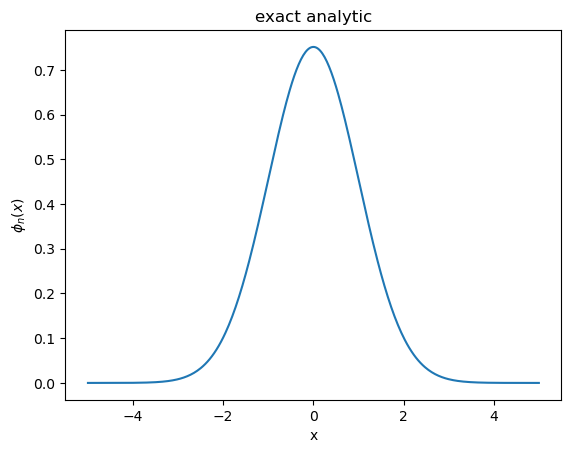

In [4]:
# plot single wave function 
n_plot=0
H0_eigenstate = cqd.hamiltonians.HO_eigenstates_exact(n_plot, xvals)

# plot exact
plt.figure()
plt.plot(xvals, H0_eigenstate)
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$\\phi_n(x)$")
plt.show()

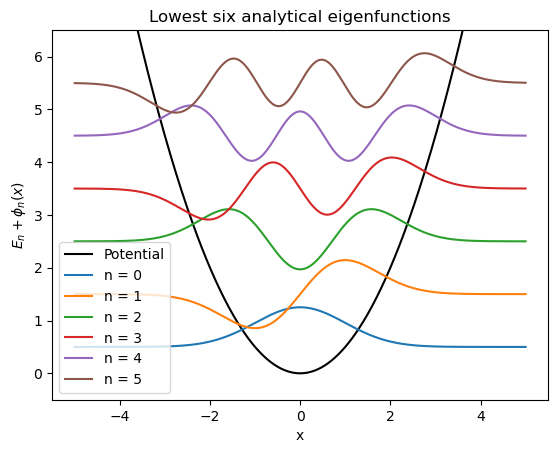

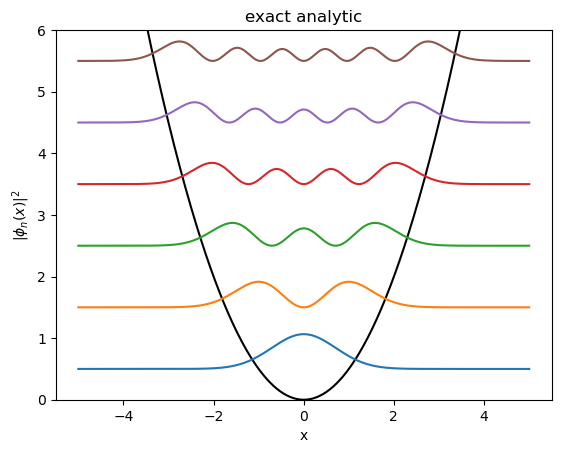

In [5]:
# Plot the lowest 6 eigenfunctions

plt.figure()
plt.plot(xvals, xvals**2 / 2, 'k', label="Potential")

for n in range(6):
    phi = cqd.hamiltonians.HO_eigenstates_exact(n, xvals)
    energy = n + 0.5
    plt.plot(xvals, energy + phi, label=f"n = {n}")
    
plt.title("Lowest six analytical eigenfunctions")
plt.xlabel("x")
plt.ylabel("$E_n + \phi_n(x)$")
plt.ylim(-0.5, 6.5)
plt.legend()
plt.show()


# plot probability density for 6 lowest eigenstates
# plot exact
plt.figure()
plt.plot(xvals,xvals**2/2,'k')
for n in range(0,6):
    plt.plot(xvals, n + 0.5 + np.abs(cqd.hamiltonians.HO_eigenstates_exact(n,xvals) ** 2))
plt.title("exact analytic")
plt.xlabel("x")
plt.ylabel("$|\\phi_n(x)|^2$")
plt.ylim([0,6])
plt.show()

### Exercise 2

Solve the eigenproblem using numpy.linalg.eigh().
Use a grid size of 20 length units and 401 gridpoints as a test case and plot the lowest 6 eigenfunctions.

Hints: eigh() is for Hermitian matrices, which have real eigenvalues. It returns the eigenvalues and eigenvectors already sorted with increasing eigenvalues. You could also use numpy.linalg.eig(), which also works for matrices with in general complex eigenvalues, but then you would have to sort them to get the ground state and lowest lying excited states, e.g. using np.argsort(). Remember that the eigenvectors are the *columns* of the array returned by eigh()!

Useful functions: np.diag(), np.ones()

Set up the problem and solve it using eigh().

In [6]:
# define the grid
L = 20
npoints = 401
dx = L/(npoints - 1)
xvals = np.linspace(-L/2,L/2,npoints)

# build the terms of the Hamiltonian
H_pot = cqd.hamiltonians.HO_potential(xvals)
H_kin = cqd.hamiltonians.H_kinetic(xvals)
H_mat = H_pot + H_kin

# evals, evecs = LA.eig(H_mat)
evals, evecs = LA.eigh(H_mat)

# If you choose eig() instead, replace the eigh() line with this block:
# evals, evecs = LA.eig(H_mat) same thing with LA.eigh()

# # sort the eigenvalues and eigenfunctions in ascending order:
# indOrder = np.argsort(evals)
indOrder = np.argsort(evals)
print("indOrder", indOrder)

# evalsSrt = evals[indOrder]
evalsSrt = evals[indOrder]
print("evalsSrt", evalsSrt)

# evecsSrt = evecs[:,indOrder]
evecsSrt = evecs[indOrder]
print("evecsSrt", evecsSrt)

indOrder [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 2

[0.49992186 1.49960927 2.49898395 3.49804576 4.49679456 5.4952302
 6.49335253 7.49116141 8.48865667 9.48583819]


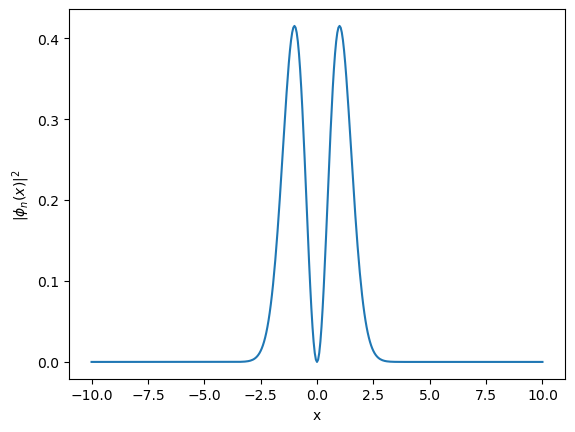

In [7]:
print(evals[0:10])

n_plot = 1
plt.plot(xvals,np.abs(evecs[:,n_plot])**2/dx)
plt.xlabel("x")
plt.ylabel("$|\\phi_n(x)|^2$")
plt.show()

Lowest six energies:
[0.49992186 1.49960927 2.49898395 3.49804576 4.49679456 5.4952302 ]


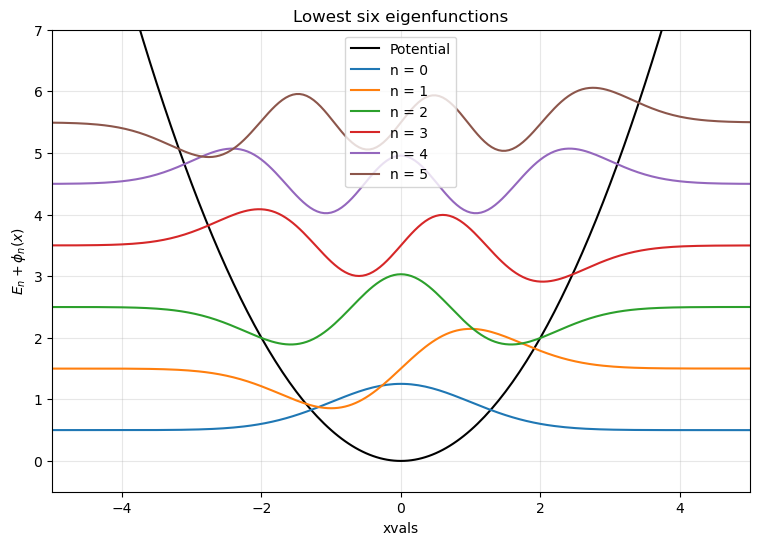

In [8]:
# Solve H phi_n = E_n phi_n
evals, evecs = LA.eigh(H_mat)

print("Lowest six energies:")
print(evals[:6])

# Normalize so that sum(|phi|²) * dx = 1
phi = evecs / np.sqrt(dx)

# Plot eigenfunctions shifted by their energies
plt.figure(figsize=(9, 6))
plt.plot(xvals, xvals**2 / 2, "k", label="Potential")

for n in range(6):
    plt.plot(xvals, evals[n] + phi[:, n], label=f"n = {n}")

plt.xlabel("xvals")
plt.ylabel(r"$E_n + \phi_n(x)$")
plt.title("Lowest six eigenfunctions")
plt.xlim(-5, 5)
plt.ylim(-0.5, 7)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Print the resulting lowest eigenvalues and plot eigenfunctions

### Exercise 3 (optional)

Having shown that the numerical diagonalization qualitatively gives the desired result, we now want to analyse its precision more quantitatively.

Check the convergence of the numerical solutions with respect to grid size and spacing. Compare the eigenvalues and eigenfunction to the analytical solutions.

Which eigenvalue has the smallest numerical error and why?

Calculate the ground state energy for different grid sizes and grid spacings and compare to the analytical solution. A systematic analysis is not necessary. Just check what happens if you use a too small grid or too few grid points.

Compare the numerically obtained eigenfunctions to the analytical solution by plotting them on top of each other. You will notice that they are normalized differently. Why is this? How to normalize the eigenvectors obtained by exact diagonalization "properly"? Plot the difference between the probability densities of the analytical and (properly normalized) numerical solution.

In [9]:
# define the grid
L = 10
npoints = 401
dx = L/(npoints - 1)
xvals = np.linspace(-L/2,L/2,npoints)

# build the terms of the Hamiltonian
H_pot = cqd.hamiltonians.HO_potential(xvals)
H_kin = cqd.hamiltonians.H_kinetic(xvals)

H_mat = H_pot + H_kin

# diagonalize: here the whole magic is happening
evals, evecs = LA.eigh(H_mat)

In [10]:
#check that the state is normalized (if we want the integral to be normalized we have to divide by dx)
n_plot = 0
LA.norm(evecs[:,n_plot])

np.float64(1.0)

In [11]:
# check convergence: relative error of eigenvalues
evals_exact = cqd.hamiltonians.HO_eigenenergies_exact(np.arange(evals.size))
(evals - evals_exact)[0:20]

array([-1.95319528e-05, -9.76601996e-05, -2.53865564e-04, -4.87361170e-04,
       -7.90577087e-04, -1.10986864e-03, -1.15489203e-03,  2.86671419e-04,
        7.09895580e-03,  2.86798873e-02,  8.18879166e-02,  1.88880288e-01,
        3.70995957e-01,  6.43465548e-01,  1.01443931e+00,  1.48706863e+00,
        2.06191756e+00,  2.73850365e+00,  3.51603758e+00,  4.39371655e+00])

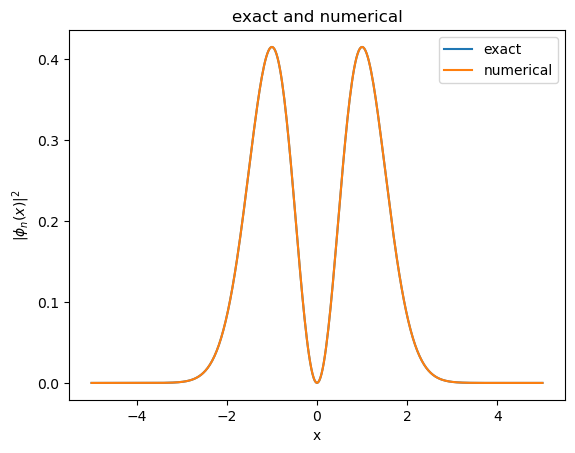

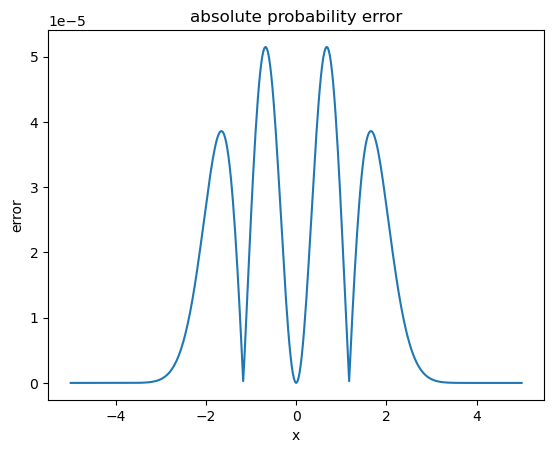

In [12]:
n_plot = 1

# compare exact to numerical
plt.figure()
plt.plot(xvals, np.abs(cqd.hamiltonians.HO_eigenstates_exact(n_plot, xvals)) ** 2, label = "exact")
plt.plot(xvals, np.abs(evecs[:,n_plot])**2 / dx, label = "numerical")
plt.title("exact and numerical")
plt.xlabel("x")
plt.ylabel("$|\\phi_n(x)|^2$")
plt.legend()

# plot relative error
plt.figure()
plt.plot(xvals, np.abs(np.abs(cqd.hamiltonians.HO_eigenstates_exact(n_plot, xvals)) ** 2 - np.abs(evecs[:, n_plot]) ** 2 / dx))
plt.title("absolute probability error")
plt.xlabel("x")
plt.ylabel("error");

Observations:

If the grid is too small, the ground state wave function gets narrower due to the hard wall boundary conditions. All the eigenenergies lie above the exact ones.

If too few gridpoints are used, the curvature of the wave function at the center is not well resolved. The numerically obtained energies are below the exact ones, probably because the kinetic term is underestimated.

### Exercise 4 (optional)

We can now use our routine to calculate bound states in any kind of potentials, where no analytical solutions are known. As an example, consider the double well potential
$$
V(x)=-\frac{1}{2}x^2 + \lambda x^4
$$
where $\lambda$ controls the height of the barrier between the wells. 

Calculate eigenvalues and eigenfunction for some values of lambda. Plot the lowest few eigenstates and interpret your results. 

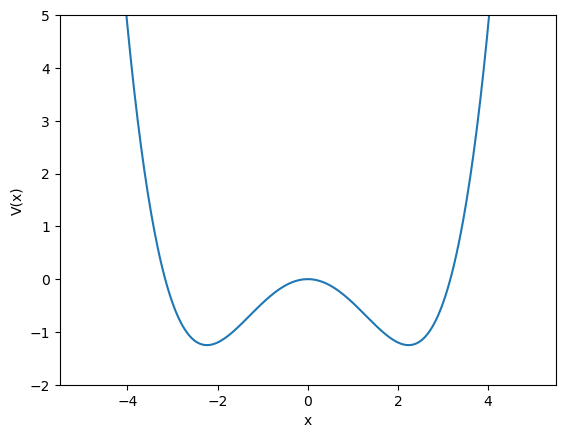

In [13]:
L = 10
npoints = 401
dx = L/(npoints - 1)
xvals = np.linspace(-L / 2, L / 2, npoints)
 
# potential
Vvec = -0.5 * xvals ** 2 + 0.05 * xvals ** 4 # double well

# plot potential
plt.plot(xvals,Vvec)
plt.ylim(-2,5)
plt.xlabel("x")
plt.ylabel("V(x)")

H_pot_dw = np.diag(Vvec)
H_kin = cqd.hamiltonians.H_kinetic(xvals)

H_mat_dw = H_pot_dw + H_kin

# diagonalize: here the whole magic is happening
evals_dw, evecs_dw = LA.eigh(H_mat_dw)

[-0.63277253 -0.57656147  0.2546729   0.77156643  1.55214122  2.4172843
  3.37718232  4.41560659  5.52450053  6.69763651  7.93070733  9.22126177
 10.56894129 11.97572344 13.44588601 14.98547614 16.6013334  18.30000105
 20.08691893 21.96608896]


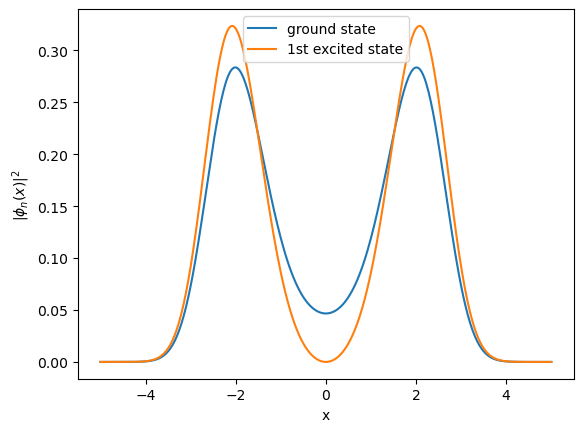

In [14]:
print(evals_dw[0:20])
#plt.plot(xvals,evecs[:,0]/dx)
#plt.plot(xvals,evecs[:,3]/dx)
plt.plot(xvals, np.abs(evecs_dw[:,0] ** 2) / dx, label = "ground state")
plt.plot(xvals, np.abs(evecs_dw[:,1] ** 2) / dx, label = "1st excited state")
plt.xlabel("x")
plt.ylabel("$|\\phi_n(x)|^2$")
plt.legend();

For small $\lambda$ (high barrier) the low lying eigenvalues of the double well come in pairs. The corresponding eigenfunctions are pairs with different symmetry. Their envelopes look quite similar. This means that there are two almost independent HOs that are weakly tunnel coupled.